# **Exercises**

# **Question 1**

```
1. Try to build a classifier for the MNIST dataset that achieves over 97% accuracy
on the test set. Hint: the KNeighborsClassifier works quite well for this task;
you just need to find good hyperparameter values (try a grid search on the
weights and n_neighbors hyperparameters).
```



so its multilabel from 0 to 9, we will use multioutput multi classifier

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler


In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)


In [3]:
print(len(X))
print(len(y))


70000
70000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [5]:
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

52500
52500
17500
17500


In [6]:
# y0 = (y_train.astype(int) ==  0)
# y1 = (y_train.astype(int) ==  1)
# y2 = (y_train.astype(int) ==  2)
# y3 = (y_train.astype(int) ==  3)
# y4 = (y_train.astype(int) ==  4)
# y5 = (y_train.astype(int) ==  5)
# y6 = (y_train.astype(int) ==  6)
# y7 = (y_train.astype(int) ==  7)
# y8 = (y_train.astype(int) ==  8)
# y9 = (y_train.astype(int) ==  9)

In [7]:
# y_multilabel = np.c_[y0,y1,y2,y3,y4,y5,y6,y7,y8,y9]

In [8]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('ss', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


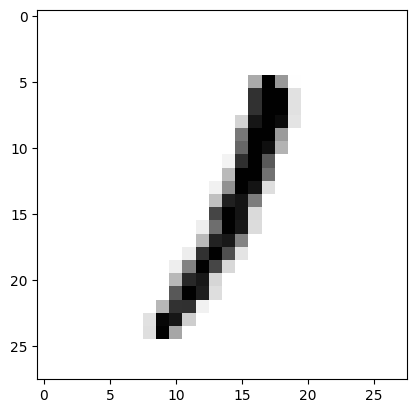

In [13]:
import matplotlib
digit_image = digit.reshape(28,28)

%matplotlib inline
plt.imshow(digit_image, cmap=matplotlib.cm.binary, interpolation='nearest')
plt.show()

In [9]:
param_grid = {
    'knn__n_neighbors': [3,5,7,9],
    'knn__weights': ['distance', 'uniform'],
}


# ------------- model ----------------

# (n_neighbors: int = 5, *, weights: str = "uniform", algorithm: str = "auto", leaf_size: int = 30, p: int = 2, metric: str = "minkowski", metric_params: Any | None = None, n_jobs: Any | None = None) -> KNeighborsClassifier

In [10]:
# (estimator: Any, param_grid: Any, *, scoring: Any | None = None, n_jobs: Any | None = None, refit: bool = True, cv: Any | None = None, verbose: int = 0, pre_dispatch: str = "2*n_jobs", error_score: float = np.nan, return_train_score: bool = False) -> GridSearchCV

gscv = GridSearchCV(pipe, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')
gscv

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('ss', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [3, 5, 7, 9],
                         'knn__weights': ['distance', 'uniform']},
             scoring='accuracy', verbose=2)

In [17]:
gscv.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=4,
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [18]:
gscv.best_params_

{'n_neighbors': 3, 'weights': 'distance'}

In [19]:
gscv.best_estimator_

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [20]:
gscv.cv_results_

{'mean_fit_time': array([1.41361237, 1.05351949, 0.74063532, 0.52049239, 0.62930759,
        0.62454796, 0.6184814 , 0.47264425]),
 'std_fit_time': array([0.45071313, 0.48099647, 0.10832786, 0.03071972, 0.05552017,
        0.12549845, 0.16893423, 0.0538624 ]),
 'mean_score_time': array([192.74787092, 169.46167699, 162.61599517, 164.89799515,
        159.58832892, 160.36327346, 159.25320005, 158.53760688]),
 'std_score_time': array([ 1.68502646, 15.71492035,  2.53392752,  0.97254153,  3.16713304,
         2.93645741,  1.67351783,  1.12274099]),
 'param_n_neighbors': masked_array(data=[3, 3, 5, 5, 7, 7, 9, 9],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=999999),
 'param_weights': masked_array(data=['uniform', 'distance', 'uniform', 'distance',
                    'uniform', 'distance', 'uniform', 'distance'],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=

In [25]:
accuracy = gscv.best_estimator_.score(X_test, y_test)
print()

0.9721714285714286


# **Question 2**


```
2. Write a function that can shift an MNIST image in any direction (left, right, up,
or down) by one pixel.5 Then, for each image in the training set, create four shif‐
ted copies (one per direction) and add them to the training set. Finally, train your
best model on this expanded training set and measure its accuracy on the test set.
You should observe that your model performs even better now! This technique of artificially growing the training set is called data augmentation or training set
expansion.
```

In [11]:
def shift_image(image, direction):

    img = image.reshape(28, 28)

    shifted = np.zeros_like(img)

    if direction == "left":
        shifted[:, :-1] = img[:, 1:]
    elif direction == "right":
        shifted[:, 1:] = img[:, :-1]
    elif direction == "up":
        shifted[:-1, :] = img[1:, :]
    elif direction == "down":
        shifted[1:, :] = img[:-1, :]
    else:
        raise ValueError("Invalid direction")

    return shifted.reshape(-1)

In [12]:
X_aug = []
y_aug = []
for image, label in zip(X_train, y_train):

  X_aug.append(image)
  y_aug.append(label)

  X_aug.append(shift_image(image, 'left'))
  X_aug.append(shift_image(image, 'right'))
  X_aug.append(shift_image(image, 'up'))
  X_aug.append(shift_image(image, 'down'))

  y_aug.extend([label,label,label,label])

X_train_aug = np.array(X_aug)
y_train_aug = np.array(y_aug)

In [ ]:
pipe = Pipeline([
    ('ss', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=3,
        weights='distance'
    ))
])

Pipeline(steps=[('ss', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])

In [18]:
pipe.fit(X_train_aug, y_train_aug)


Pipeline(steps=[('ss', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])

In [19]:
accuracy = pipe.score(X_test, y_test)

In [20]:
print(accuracy)

0.9603428571428572


# **Question 4**
```
4. Build a spam classifier (a more challenging exercise):
• Download examples of spam and ham from Apache SpamAssassin’s public
datasets.
• Unzip the datasets and familiarize yourself with the data format.
• Split the datasets into a training set and a test set.
• Write a data preparation pipeline to convert each email into a feature vector.
Your preparation pipeline should transform an email into a (sparse) vector
indicating the presence or absence of each possible word. For example, if all
emails only ever contain four words, “Hello,” “how,” “are,” “you,” then the email
“Hello you Hello Hello you” would be converted into a vector [1, 0, 0, 1]
(meaning [“Hello” is present, “how” is absent, “are” is absent, “you” is
present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of
each word.
• You may want to add hyperparameters to your preparation pipeline to control
whether or not to strip off email headers, convert each email to lowercase,
remove punctuation, replace all URLs with “URL,” replace all numbers with
“NUMBER,” or even perform stemming (i.e., trim off word endings; there are
Python libraries available to do this).
• Then try out several classifiers and see if you can build a great spam classifier,
with both high recall and high precision.

```

In [36]:
# import os
# import tarfile
# import urllib.request

# # Define the base URL and the files shown in your image_82ee79.png
# BASE_URL = "https://spamassassin.apache.org/old/publiccorpus/"
# FILES = [
#     "20030228_easy_ham.tar.bz2",
#     "20030228_easy_ham_2.tar.bz2",
#     "20030228_spam.tar.bz2",
#     "20030228_spam_2.tar.bz2"
# ]
DEST_DIR = "spam_data"

# def fetch_and_extract():
#     if not os.path.exists(DEST_DIR):
#         os.makedirs(DEST_DIR)

#     for filename in FILES:
#         filepath = os.path.join(DEST_DIR, filename)
#         url = BASE_URL + filename
        
#         print(f"Downloading {filename}...")
#         urllib.request.urlretrieve(url, filepath)
        
#         print(f"Extracting {filename}...")
#         with tarfile.open(filepath, "r:bz2") as tar:
#             tar.extractall(path=DEST_DIR)
        
#         # Optional: Remove the compressed file to save space
#         os.remove(filepath)

# if __name__ == "__main__":
#     # fetch_and_extract()
#     print("Done! Data is ready in the 'spam_data' directory.")

In [37]:
import os

if not os.path.exists(DEST_DIR):
    raise ValueError(f"DEST_DIR does not exist.")
else:
    total = 0
    for item in os.listdir(DEST_DIR):    
        EACH_DIR = os.path.join(DEST_DIR, item)
        if os.path.isdir(EACH_DIR):
            contents = os.listdir(EACH_DIR)
            total += len(contents)
            print(f"Folder: {item} | Items inside: {len(contents)}")
        else:
            print(f"File: {item} | (Skipping count)")
        
    print("Total: ", total)


Folder: easy_ham | Items inside: 2500
Folder: spam | Items inside: 500
Folder: easy_ham_2 | Items inside: 1400
File: Spamdataset.csv | (Skipping count)
Folder: spam_2 | Items inside: 1397
Total:  5797


```
• Split the datasets into a training set and a test set.

• Write a data preparation pipeline to convert each email into a feature vector.
Your preparation pipeline should transform an email into a (sparse) vector
indicating the presence or absence of each possible word. For example, if all
emails only ever contain four words, “Hello,” “how,” “are,” “you,” then the email
“Hello you Hello Hello you” would be converted into a vector [1, 0, 0, 1]
(meaning [“Hello” is present, “how” is absent, “are” is absent, “you” is
present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of
each word.
```

In [31]:
import os
import pandas as pd
import numpy as np

DEST_DIR = "spam_data"
X = []
y = []

if not os.path.exists(DEST_DIR):
    raise ValueError(f"DEST_DIR does not exist.")


for item in os.listdir(DEST_DIR):

    dir_path = os.path.join(DEST_DIR, item)
    
    if item in ['easy_ham', 'easy_ham_2']:
        label = 0
    elif item in ['spam', 'spam_2']:
        label = 1
    else:
        continue
    
    contents = os.listdir(dir_path)
        
    for file_name in contents:
        
        full_file_path = os.path.join(dir_path, file_name)
            
        if os.path.isfile(full_file_path):
            try:
                with open(full_file_path, 'r', encoding='latin-1') as f:
                    data = f.read()
                    X.append(data)
                    y.append(label)
            except Exception as e:
                print(f"Skipping file {file_name} due to error: {e}")
        else:
            print(f"{full_file_path} is not a file.")                 
            

In [32]:
print(len(X))
print(len(y))

5797
5797


In [33]:
df = pd.DataFrame({
    'emails': X,
    'label': y
})

df.to_csv(r'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/spam_data/Spamdataset.csv', index=False)


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv(r"/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/spam_data/Spamdataset.csv")
df

,emails,label
0,From spamassassin-talk-admin@lists.sourceforge...,0
1,From rssfeeds@jmason.org Tue Oct 1 10:37:37 ...,0
2,From ilug-admin@linux.ie Tue Oct 8 12:26:48 ...,0
3,From fork-admin@xent.com Mon Sep 30 13:52:45 ...,0
4,From fork-admin@xent.com Thu Aug 29 11:03:51 ...,0
...,...,...
5792,From ncprankservice@blueyonder.co.uk Wed Jul ...,1
5793,From fork-admin@xent.com Mon Jul 22 18:14:02 ...,1
5794,From fork-admin@xent.com Fri Jul 19 03:09:29 ...,1
5795,From ehbzk@371.net Mon Jun 24 17:03:26 2002\n...,1


In [38]:
X = df['emails']
y = df['label']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=df['label'])

In [40]:
print('X_train: ',len(X_train))
print('X_test: ',len(X_test))
print('y_train: ',len(y_train))
print('y_test: ',len(y_test))

X_train:  4637
X_test:  1160
y_train:  4637
y_test:  1160


In [47]:
print("Train distribution: ", y_train.value_counts(normalize=True))
print()
print("Test distribution: ", y_test.value_counts(normalize=True))
print()
print("X_train Sample: ",X_train[0])
print()
print("X_test Sample: ",X_test[1])
print()


Train distribution:  label
0    0.672849
1    0.327151
Name: proportion, dtype: float64

Test distribution:  label
0    0.672414
1    0.327586
Name: proportion, dtype: float64

X_train Sample:  From spamassassin-talk-admin@lists.sourceforge.net  Thu Aug 22 16:17:10 2002
Return-Path: <spamassassin-talk-admin@example.sourceforge.net>
Delivered-To: yyyy@localhost.netnoteinc.com
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.netnoteinc.com (Postfix) with ESMTP id 163C943F99
	for <jm@localhost>; Thu, 22 Aug 2002 11:17:09 -0400 (EDT)
Received: from phobos [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for jm@localhost (single-drop); Thu, 22 Aug 2002 16:17:09 +0100 (IST)
Received: from usw-sf-list2.sourceforge.net (usw-sf-fw2.sourceforge.net
    [216.136.171.252]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id
    g7MFDmZ11714 for <jm-sa@jmason.org>; Thu, 22 Aug 2002 16:13:49 +0100
Received: from usw-sf-list1-b.sourceforge.net ([10.3.1.13]
    helo=usw-sf-list1

In [ ]:
# Source - https://stackoverflow.com/q/265960
# Posted by Redwood, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-13, License - CC BY-SA 4.0

# import string
# s = "string. With. Punctuation?"
# out = s.translate(string.maketrans("",""), string.punctuation)


def preprocessing_pipeline(X):
    
    for data in X:
        data = data.lower()
        # print(type(data)) # so its <class 'str'>
        
        
        
        
        
        
        
        
        
        
        break
        
        
        
        
        
    
    pass



print()


preprocessing_pipeline(X_train[0:4])


<class 'str'>
